# **DATA SCIENTIST: BREEZY_YRN**
#### Bank Customer Churn Prediction : Customer retention is a critical challenge for banking institutions, as acquiring new customers is often more expensive than retaining existing ones. This project focuses on predicting customer churn in a bank, where churn refers to customers who discontinue their relationship with the bank.The dataset contains detailed demographic, financial, and behavioral information about bank customers, along with a target variable indicating whether a customer has exited the bank. By analyzing this data, the project aims to identify key factors that influence customer churn and to build a predictive machine learning model capable of detecting customers who are at high risk of leaving the bank.The insights generated from this project can help banks take proactive retention measures, improve customer satisfaction, and reduce revenue loss by targeting at-risk customers with personalized strategies.

In [1]:
#import the required libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.ticker as mtick  
import matplotlib.pyplot as plt
%matplotlib inline




In [2]:
bank_churn = pd.read_csv(r"C:\Users\Admin\Desktop\machine learning\churn_pred\Churn_Modelling.csv")

In [3]:
bank_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
bank_churn.shape

(10000, 14)

In [5]:
bank_churn.columns.values

array(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'], dtype=object)

In [6]:
# Checking the data types of all the columns
bank_churn.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

### ANALYSIS BEGIN:

In [7]:
# Check the descriptive statistics of numeric variables
bank_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


The descriptive statistics indicate that the bank churn dataset consists of 10,000 customer records with diverse demographic, financial, and behavioral characteristics. Variables such as credit score, age, balance, tenure, and estimated salary show wide variability, suggesting differences in customer financial status and engagement with the bank. Customer engagement indicators, including number of products, credit card ownership, and active membership, vary across customers and are likely to influence churn behavior. The target variable, Exited, shows that approximately 20% of customers have left the bank, indicating a moderate class imbalance that should be considered during model training and evaluation. Overall, the dataset is well-structured and provides a strong basis for analyzing customer behavior and building predictive models for bank customer churn.

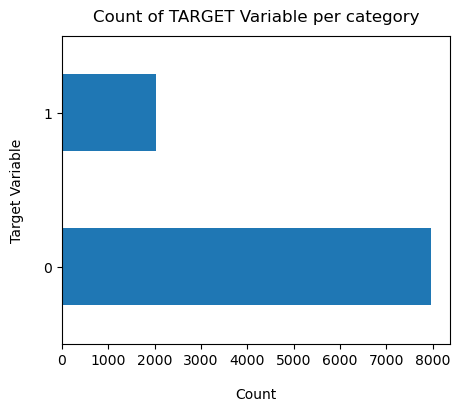

In [8]:
bank_churn['Exited'].value_counts().plot(kind='barh', figsize=(5, 4))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02);
plt.show() 

In [9]:
100*bank_churn['Exited'].value_counts()/len(bank_churn['Exited'])

Exited
0    79.63
1    20.37
Name: count, dtype: float64

In [10]:
bank_churn['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

* 0=NO   ,   1=YES
* Data is highly imbalanced, ratio = 80:20<br>
* So we analyse the data with other features while taking the target values separately to get some insights.

In [11]:
# Concise Summary of the dataframe, as we have too many columns, we are using the verbose = True mode
bank_churn.info(verbose = True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


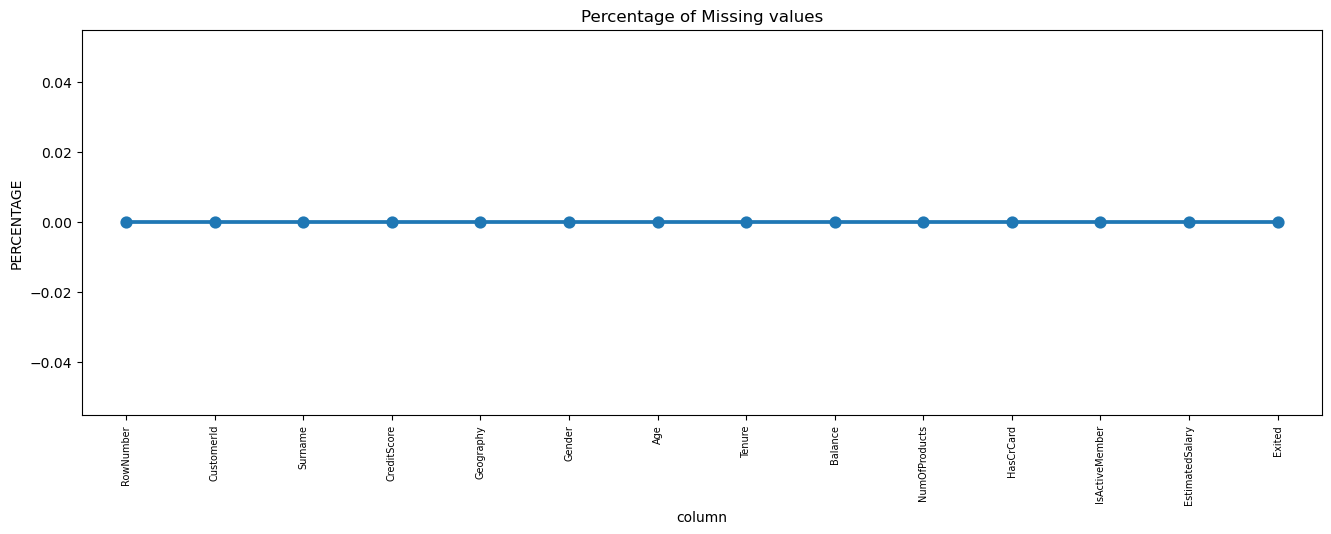

In [12]:
missing = pd.DataFrame({
    'column': bank_churn.isnull().sum().index,
    'missing_pct': bank_churn.isnull().sum().values * 100 / bank_churn.shape[0]
})
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='column', y='missing_pct', data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

### Missing Data - Initial Intuition

* Here, we don't have any missing data.

General Thumb Rules:

* For features with less missing values- can use regression to predict the missing values or fill with the mean of the values present, depending on the feature.
* For features with very high number of missing values- it is better to drop those columns as they give very less insight on analysis.
* As there's no thumb rule on what criteria do we delete the columns with high number of missing values, but generally you can delete the columns, if you have more than 30-40% of missing values. But again there's a catch here, for example, Is_Car & Car_Type, People having no cars, will obviously have Car_Type as NaN (null), but that doesn't make this column useless, so decisions has to be taken wisely.

## Data Cleaning


**1.** Create a copy of base data for manupulation & processing

In [13]:
bank_churn_1 = bank_churn.copy()

**2.** Remove columns not required for processing

In [14]:
#drop column customerID and tenure
bank_churn_1.drop(columns= ['RowNumber','CustomerId','Surname'], axis=1, inplace=True)
bank_churn_1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
bank_churn_1['Age'].unique()

array([42, 41, 39, 43, 44, 50, 29, 27, 31, 24, 34, 25, 35, 45, 58, 32, 38,
       46, 36, 33, 40, 51, 61, 49, 37, 19, 66, 56, 26, 21, 55, 75, 22, 30,
       28, 65, 48, 52, 57, 73, 47, 54, 72, 20, 67, 79, 62, 53, 80, 59, 68,
       23, 60, 70, 63, 64, 18, 82, 69, 74, 71, 76, 77, 88, 85, 84, 78, 81,
       92, 83], dtype=int64)

In [16]:
bank_churn_1['NumOfProducts'].unique()

array([1, 3, 2, 4], dtype=int64)

**3.** Divide customers into bins based on Age 

In [17]:
# Get the max Age
print(bank_churn_1['Age'].max()) #92

92


In [18]:
bins = range(18, 94, 12)
labels = [f"{i}-{i+11}" for i in range(18, 82, 12)]

bank_churn_1['Age_group'] = pd.cut(bank_churn_1['Age'],bins=bins,labels=labels,right=False)

In [19]:
bank_churn_1['Age_group'].value_counts()

Age_group
30-41    5144
42-53    2249
18-29    1641
54-65     702
66-77     240
78-89      22
Name: count, dtype: int64

In [20]:
bank_churn_1.drop(columns= ['Age'], axis=1, inplace=True)
bank_churn_1.head()

,CreditScore,Geography,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_group
0,619,France,Female,2,0.00,1,1,1,101348.88,1,42-53
1,608,Spain,Female,1,83807.86,1,0,1,112542.58,0,30-41
2,502,France,Female,8,159660.80,3,1,0,113931.57,1,42-53
3,699,France,Female,1,0.00,2,0,0,93826.63,0,30-41
4,850,Spain,Female,2,125510.82,1,1,1,79084.10,0,42-53


## Data Exploration
**1.** Plot distibution of individual predictors by churn

### Univariate Analysis

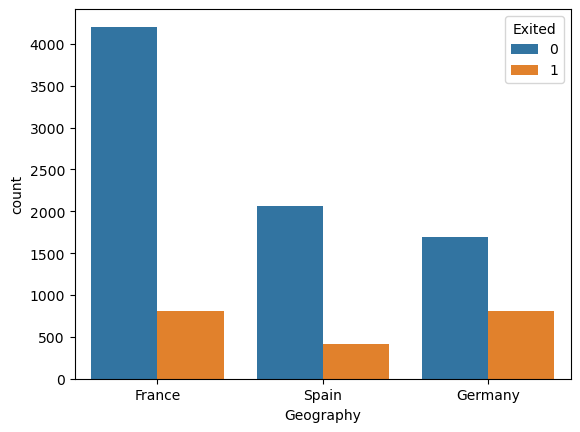

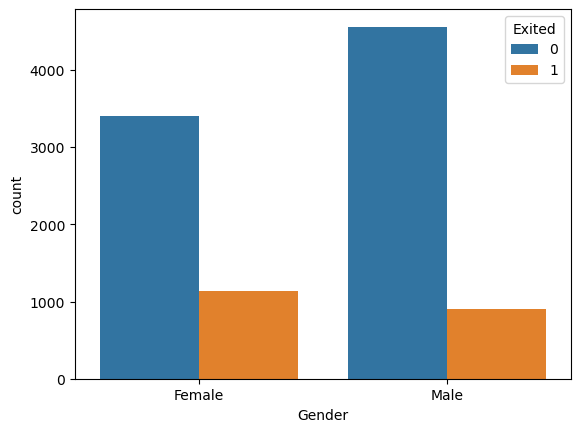

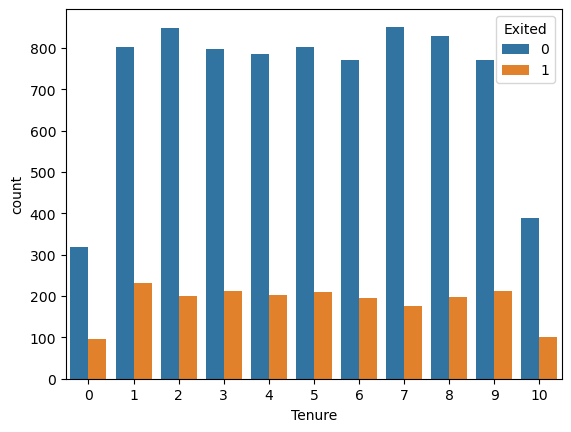

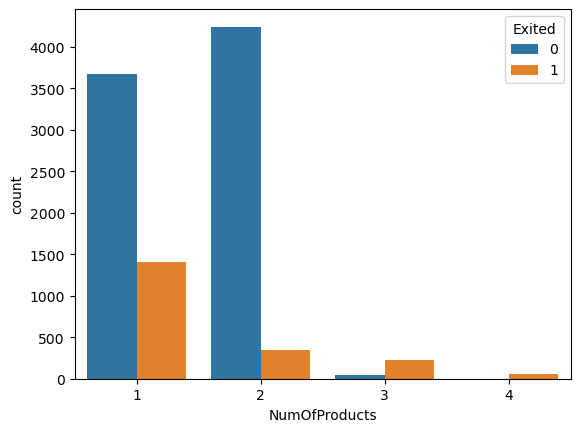

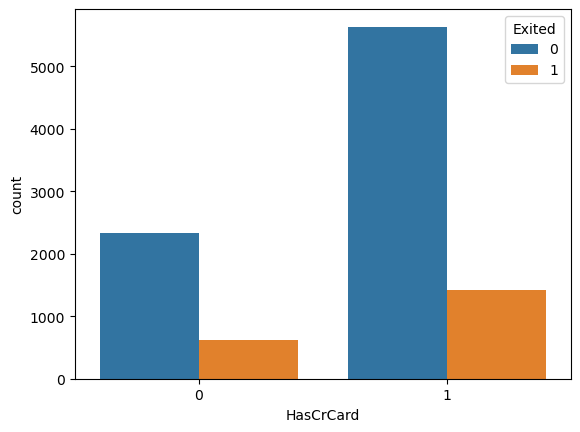

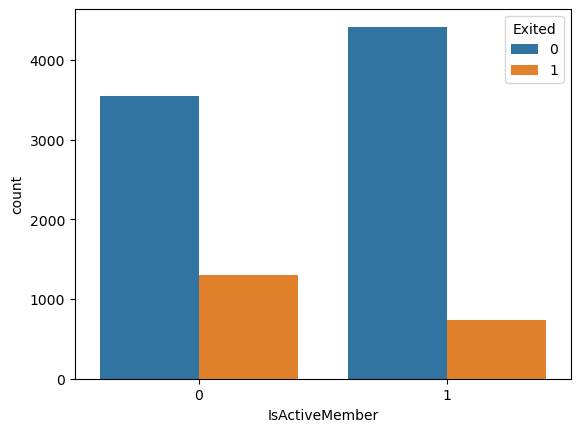

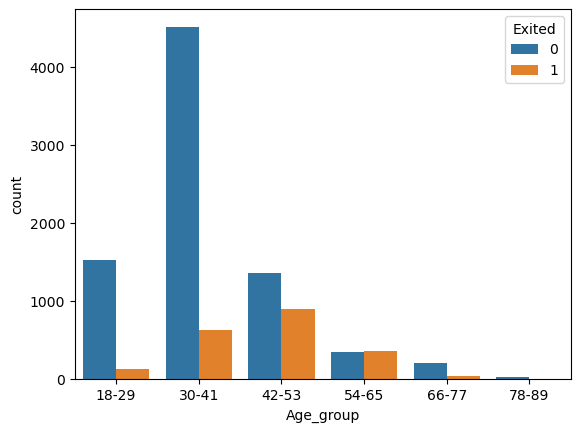

In [21]:
for i, predictor in enumerate(bank_churn_1.drop(columns=['Exited', 'CreditScore', 'Balance','EstimatedSalary'])):
    plt.figure(i)
    sns.countplot(data=bank_churn_1, x=predictor, hue='Exited')
    plt.show()

- Germany having a higher proportion of customers who exited the bank compared to France and Spain,       while Spain has the lowest churn.<br>
- Female having a higher proportion of customer who exited the bank compared to male.<br>
- Mostly of the tenure who have 0 and 10 having lower churn as compare to 1,2,3,4,5,6,7,8 and 9.<br>
- Mostly of the people who have product 1 and 2 having higher proportion.<br>
- People who have card are more churned.<br>
- Mostly of the people who is not active are more churned.<br>
- Mostly of the people who have age between 30-41 and 42-53 are more likely to churn.<br>

**2** Churn by Balance,EstimatedSalary and CreditScore

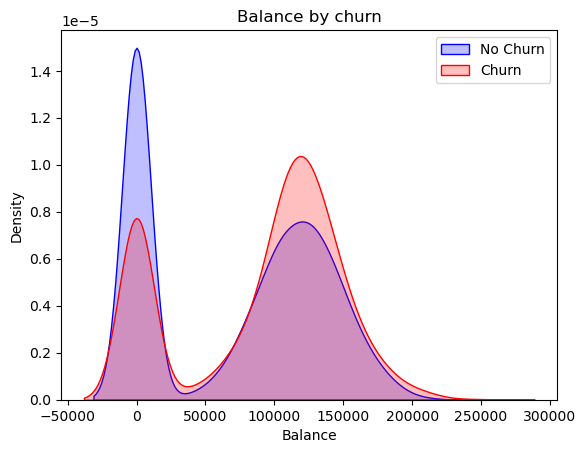

In [22]:
Mth = sns.kdeplot(bank_churn_1.Balance[(bank_churn_1["Exited"] == 0) ],
                color="Blue", fill=True)
Mth = sns.kdeplot(bank_churn_1.Balance[(bank_churn_1["Exited"] == 1) ],
                ax =Mth, color="Red", fill=True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Balance')
Mth.set_title('Balance by churn')
plt.show()

**Insight:** <br> The graph compares the distribution of account balances for customers who did not churn and those who churned. Customers who did not churn show a strong peak at low or zero balances, indicating that many retained customers maintain minimal account balances. In contrast, churned customers exhibit a higher density at larger balance values, suggesting that customers with higher account balances are more likely to exit the bank. The overlap between the two distributions indicates that balance alone does not fully determine churn; however, higher balances appear to be associated with an increased likelihood of customer churn.

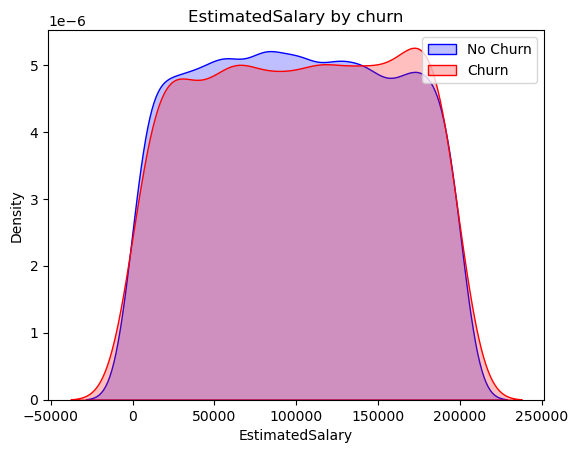

In [23]:
Mth = sns.kdeplot(bank_churn_1.EstimatedSalary[(bank_churn_1["Exited"] == 0) ],
                color="Blue", fill=True)
Mth = sns.kdeplot(bank_churn_1.EstimatedSalary[(bank_churn_1["Exited"] == 1) ],
                ax =Mth, color="Red", fill=True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('EstimatedSalary')
Mth.set_title('EstimatedSalary by churn')
plt.show()

-Estimated salary is not a strong predictor of churn, as both churned and non-churned customers show very similar salary distributions.

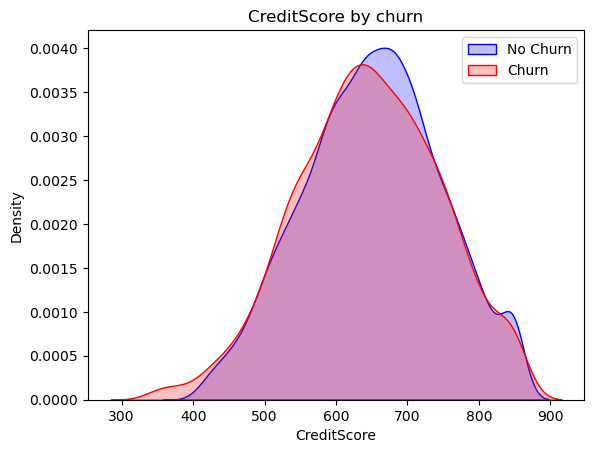

In [24]:
Mth = sns.kdeplot(bank_churn_1.CreditScore[(bank_churn_1["Exited"] == 0) ],
                color="Blue", fill=True)
Mth = sns.kdeplot(bank_churn_1.CreditScore[(bank_churn_1["Exited"] == 1) ],
                ax =Mth, color="Red", fill=True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('CreditScore')
Mth.set_title('CreditScore by churn')
plt.show()

-Customers with lower credit scores show a slightly higher likelihood of churn, but overall credit score is a weak standalone predictor of customer exit.

**3.** Build a corelation of all predictors with 'Churn' **

In [25]:
# Identify categorical columns
object_columns = bank_churn_1.select_dtypes(include=['object','category']).columns

# Apply dummy encoding
bank_churn_dummies = pd.get_dummies(
    bank_churn_1,
    columns=object_columns,
    drop_first=True,   # avoid dummy variable trap
    dtype=int
)
bank_churn_dummies.head()

,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,Age_group_30-41,Age_group_42-53,Age_group_54-65,Age_group_66-77,Age_group_78-89
0,619,2,0.00,1,1,1,101348.88,1,0,0,0,0,1,0,0,0
1,608,1,83807.86,1,0,1,112542.58,0,0,1,0,1,0,0,0,0
2,502,8,159660.80,3,1,0,113931.57,1,0,0,0,0,1,0,0,0
3,699,1,0.00,2,0,0,93826.63,0,0,0,0,1,0,0,0,0
4,850,2,125510.82,1,1,1,79084.10,0,0,1,0,0,1,0,0,0


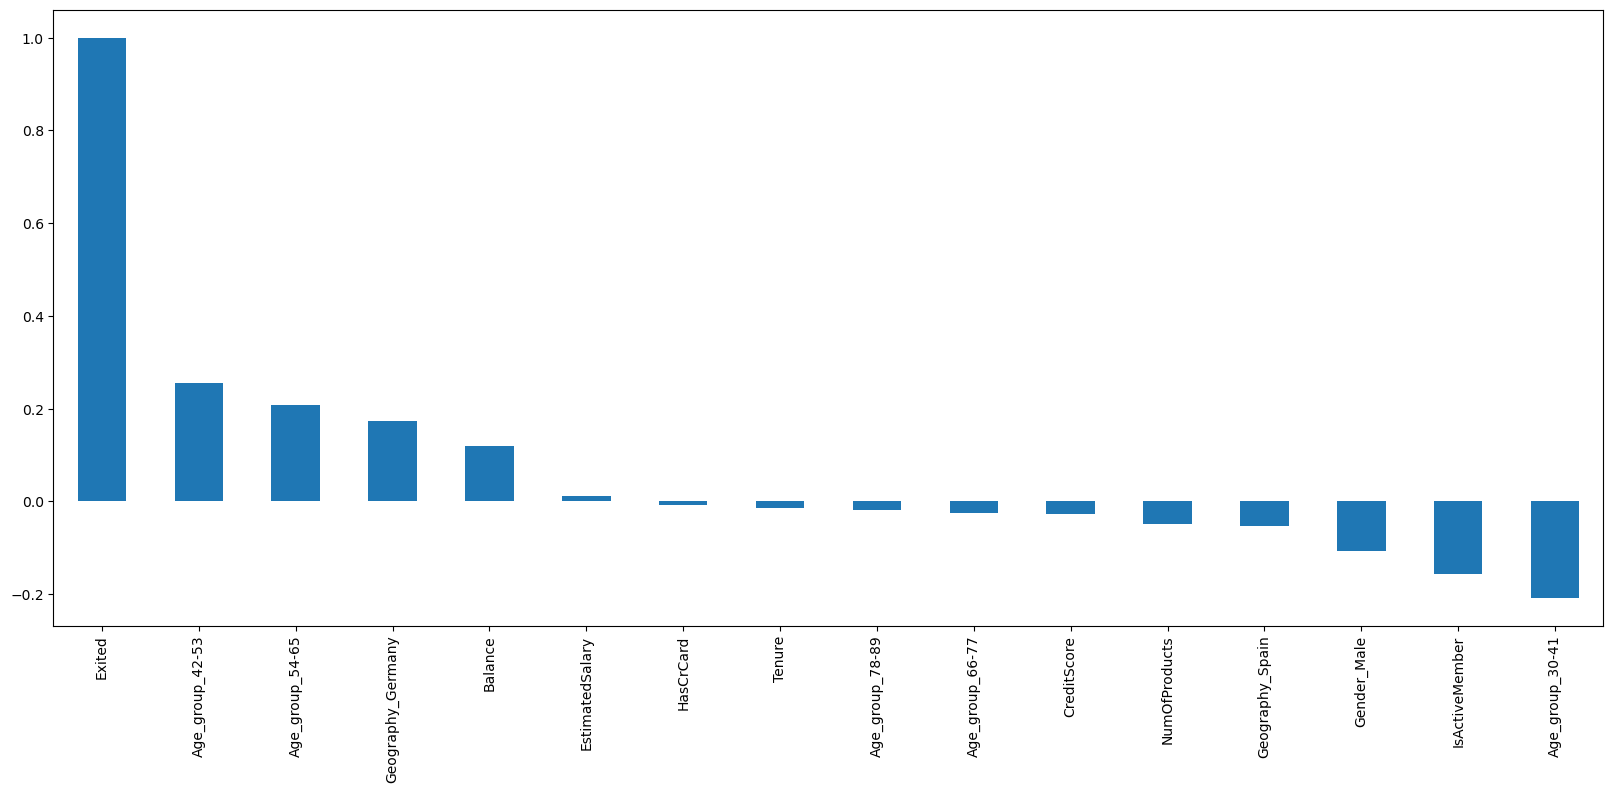

In [26]:
plt.figure(figsize=(20,8))
bank_churn_dummies.corr()['Exited'].sort_values(ascending = False).plot(kind='bar')
plt.show()

**Derived Insight:** <br>
The graph illustrates the influence of different customer attributes on the likelihood of churn (Exited). Age is the most significant factor, with customers aged 42–53 and 54–65 showing a higher probability of exiting, while younger customers aged 30–41 are more likely to remain. Geographic location also plays an important role, as customers from Germany are more prone to churn compared to those from Spain. Customer activity status is a strong protective factor, with active members being much less likely to exit. Balance has a moderate positive impact on churn, indicating that customers with higher balances tend to leave more often. In contrast, holding more products reduces the likelihood of churn. Gender shows a minor effect, with male customers slightly less likely to exit. Other variables such as estimated salary, credit card ownership, and tenure have minimal influence on customer churn.

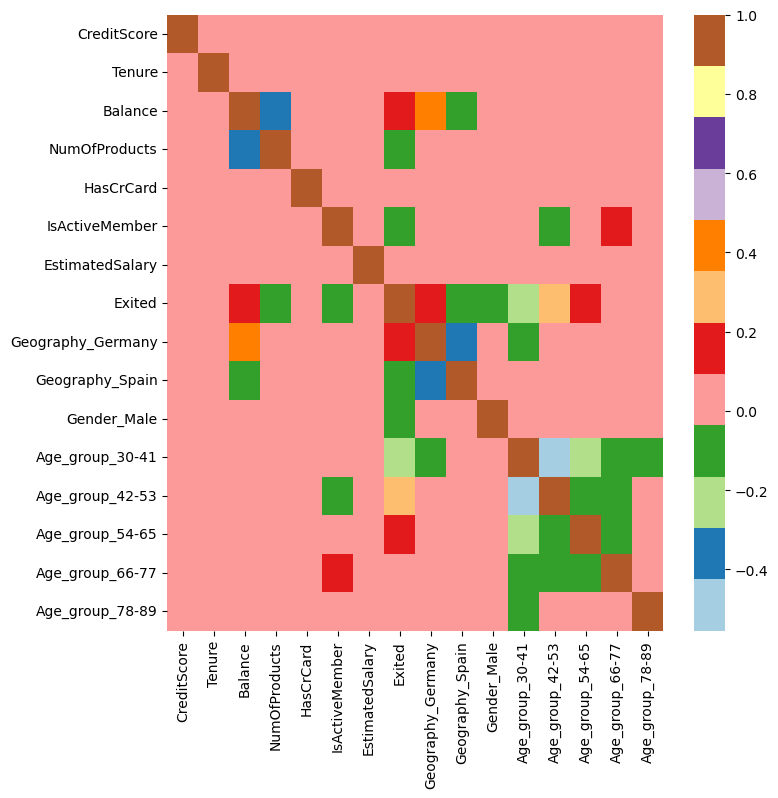

In [27]:
plt.figure(figsize=(8,8))
sns.heatmap(bank_churn_dummies.corr(), cmap="Paired")
plt.show()

### Bivariate Analysis

In [28]:
new_df1_target0=bank_churn_1.loc[bank_churn_1["Exited"]==0]
new_df1_target1=bank_churn_1.loc[bank_churn_1["Exited"]==1]

In [29]:
def uniplot(df, col, title, hue=None):

    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30

    if hue is not None:
        temp = df[hue]
        width = len(df[col].unique()) + 7 + 4 * len(temp.unique())
    else:
        width = len(df[col].unique()) + 7

    fig, ax = plt.subplots(figsize=(width, 8))
    plt.xticks(rotation=45)
    plt.title(title)

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=hue,
        palette='bright'
    )

    plt.show()


 Bivarate analysis for Geography churned and non churned 

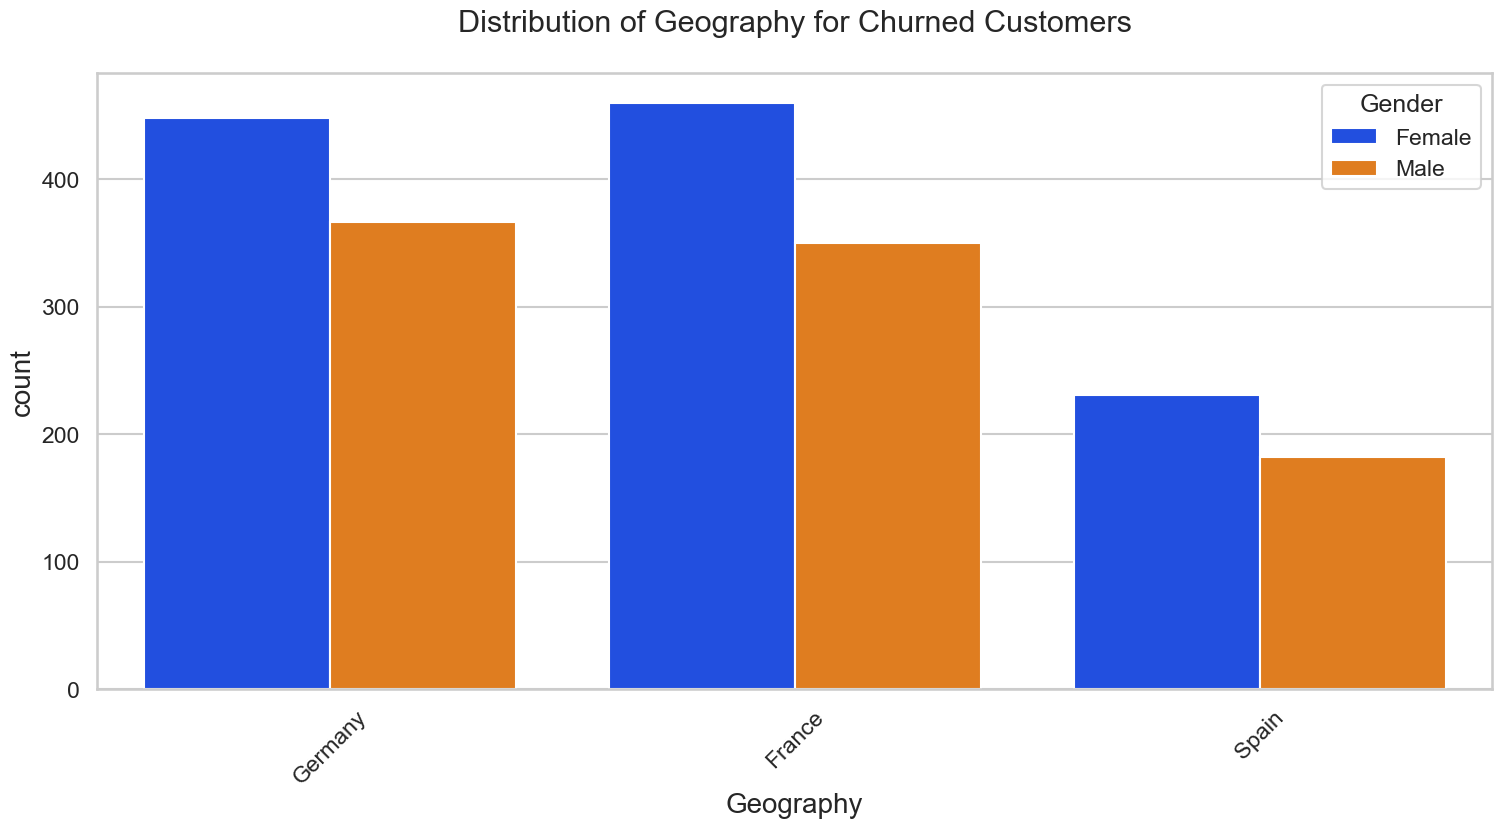

In [30]:
uniplot(
    new_df1_target1,
    col='Geography',
    title='Distribution of Geography for Churned Customers',
    hue='Gender'
)


The chart shows that customer churn is highest in France and Germany, while Spain has the lowest churn levels. Across all regions, female customers consistently churn more than male customers. France records the highest number of churned female customers, followed closely by Germany. These results suggest that geography and gender jointly influence churn, with female customers in France and Germany being the most at risk.

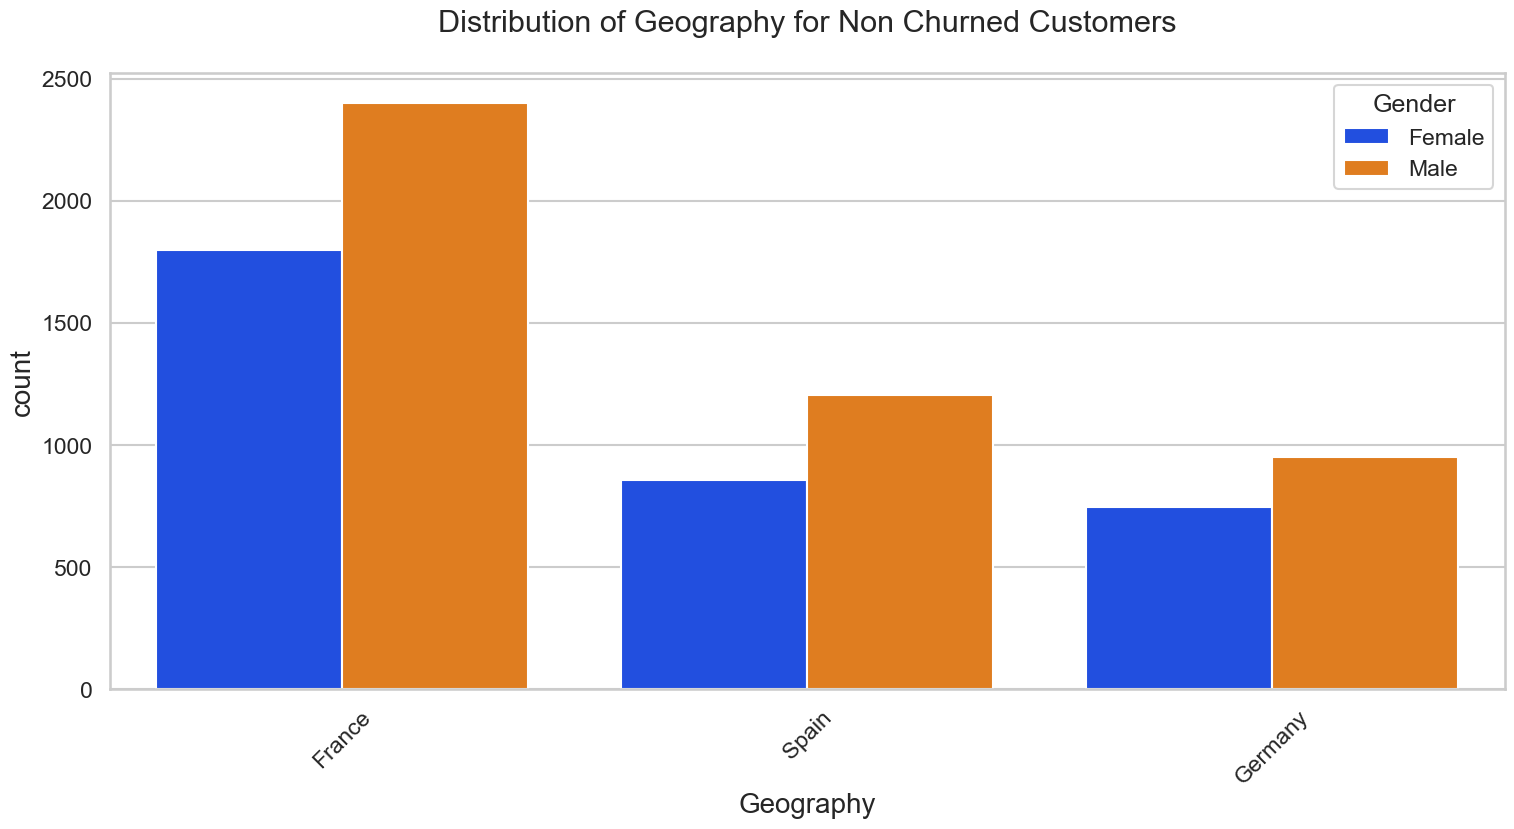

In [31]:
uniplot(
    new_df1_target0,
    col='Geography',
    title='Distribution of Geography for Non Churned Customers',
    hue='Gender'
)

since the number of female customers churned  in france  and spain are high so directly the number non churned is male across all country france,spain and germany

Bivarate analysis for NumOfProducts churned 

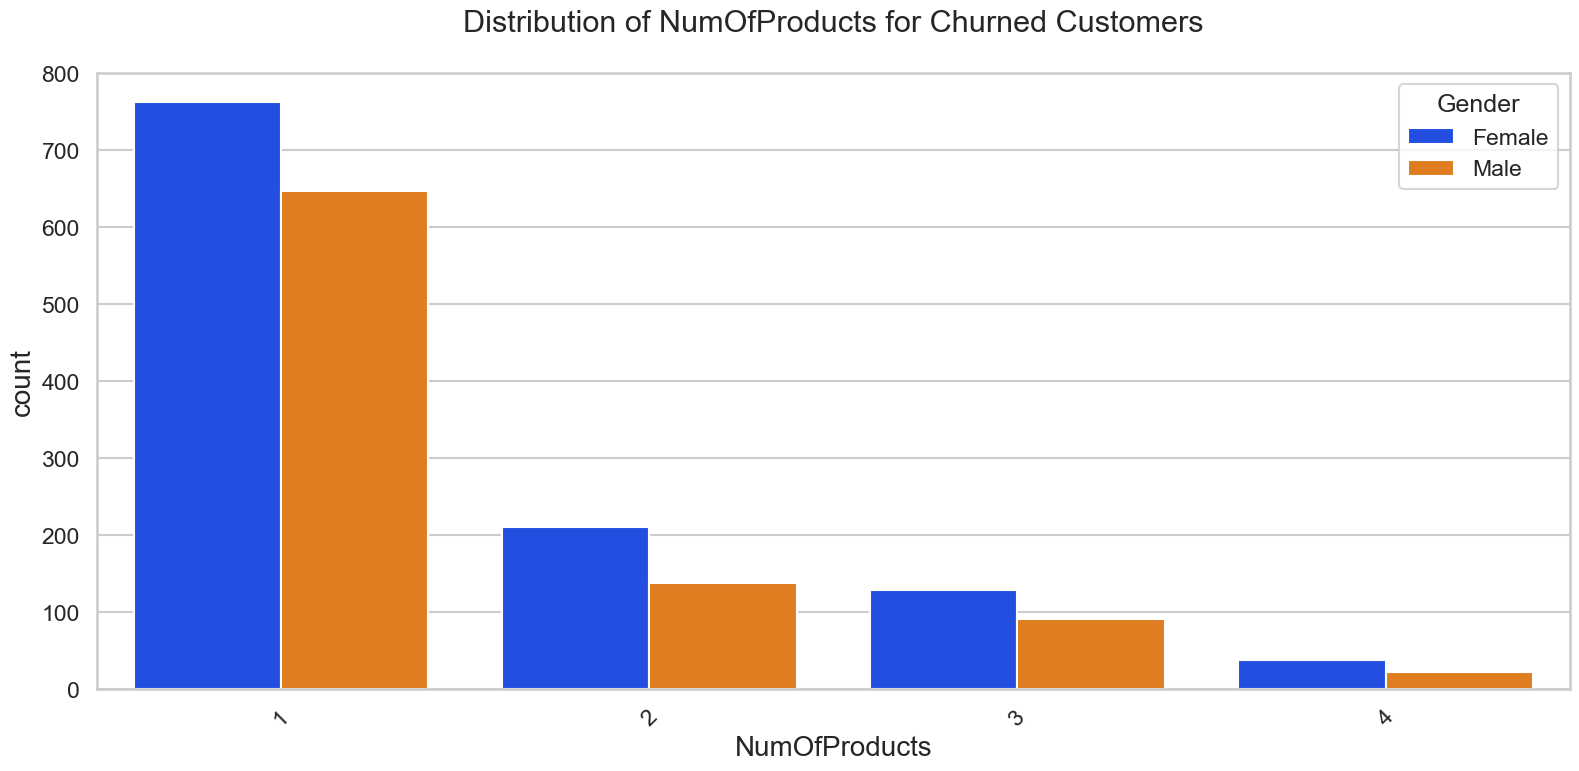

In [32]:
uniplot(
    new_df1_target1,
    col='NumOfProducts',
    title='Distribution of NumOfProducts for Churned Customers',
    hue='Gender'
)

The chart shows that customer churn is highest in product 1 , while product 2 ,product 3,product 4 have the lowest churn levels.female customers consistently churn more than male customers. product 1 records the highest number of churned female customers. These results suggest that NumOfProducts and gender jointly influence churn, with female customers in product 1 being the most at risk.

Bivarate analysis for Tenure  churned 

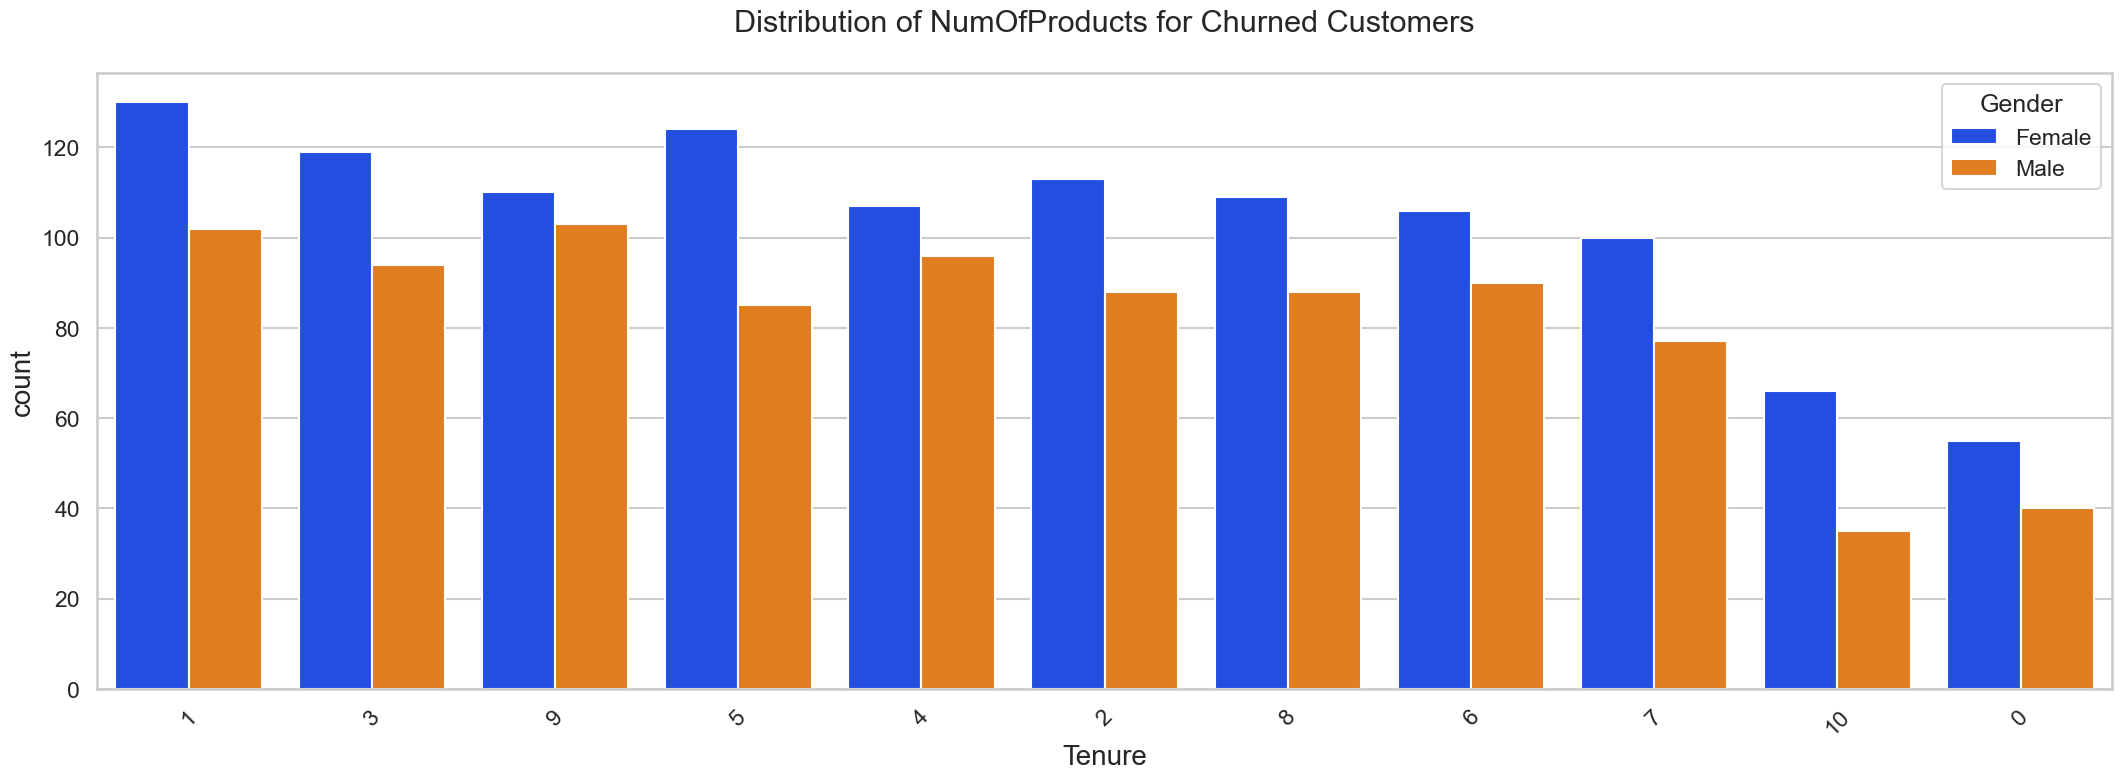

In [33]:
uniplot(
    new_df1_target1,
    col='Tenure',
    title='Distribution of NumOfProducts for Churned Customers',
    hue='Gender'
)

The graph illustrates the distribution of churned customers across different tenure levels, segmented by gender. Churn is highest among customers with shorter and mid-level tenures, indicating that customers who have not stayed long with the bank are more likely to leave. Across almost all tenure values, female customers show higher churn counts than male customers, revealing a consistent gender difference. As tenure increases, the number of churned customers generally declines, suggesting that long-tenured customers are more loyal and less likely to churn.

Bivarate analysis for HasCrCard   churned 

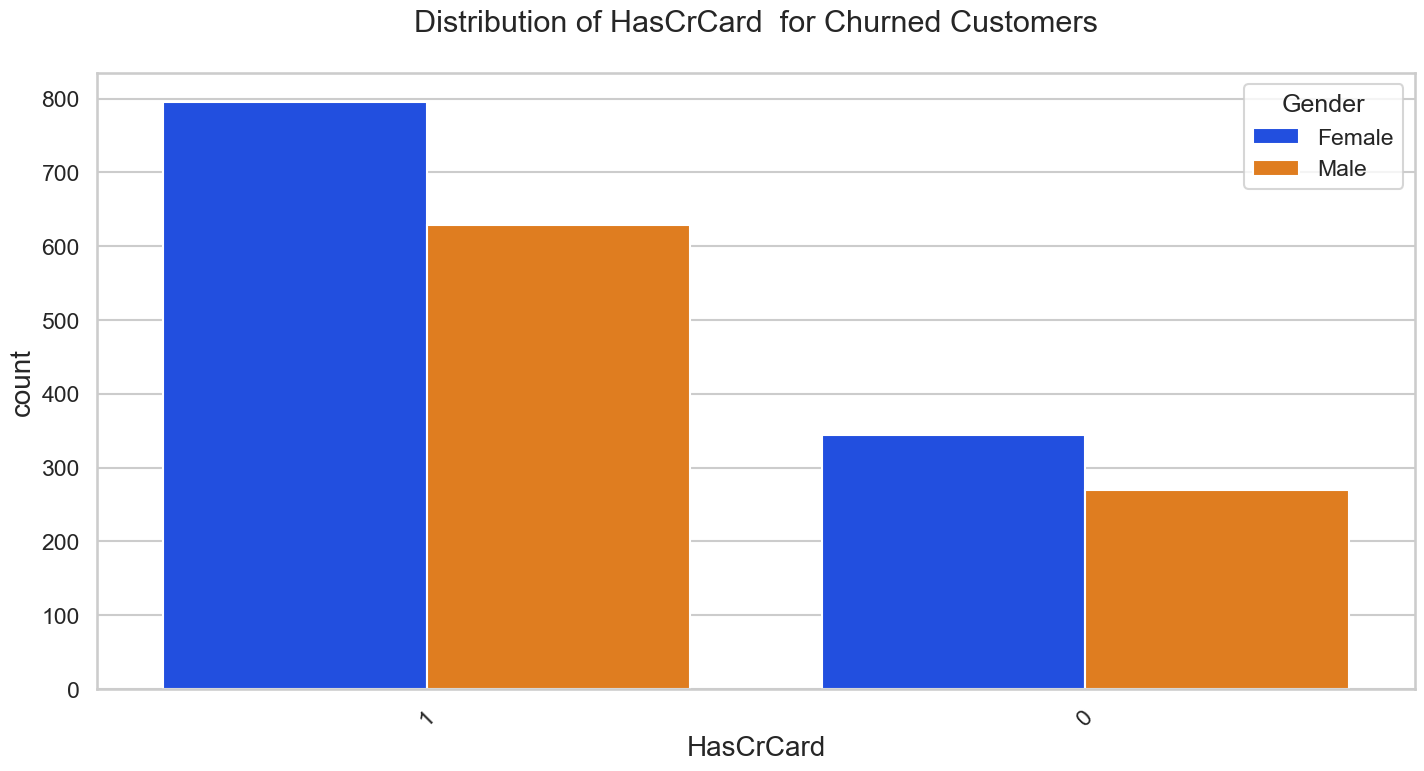

In [34]:
uniplot(
    new_df1_target1,
    col='HasCrCard',
    title='Distribution of HasCrCard  for Churned Customers',
    hue='Gender'
)

-Most of the people who has credit card especialy female are more churned as compare has no credit card

Bivarate analysis for IsActiveMember  churned 

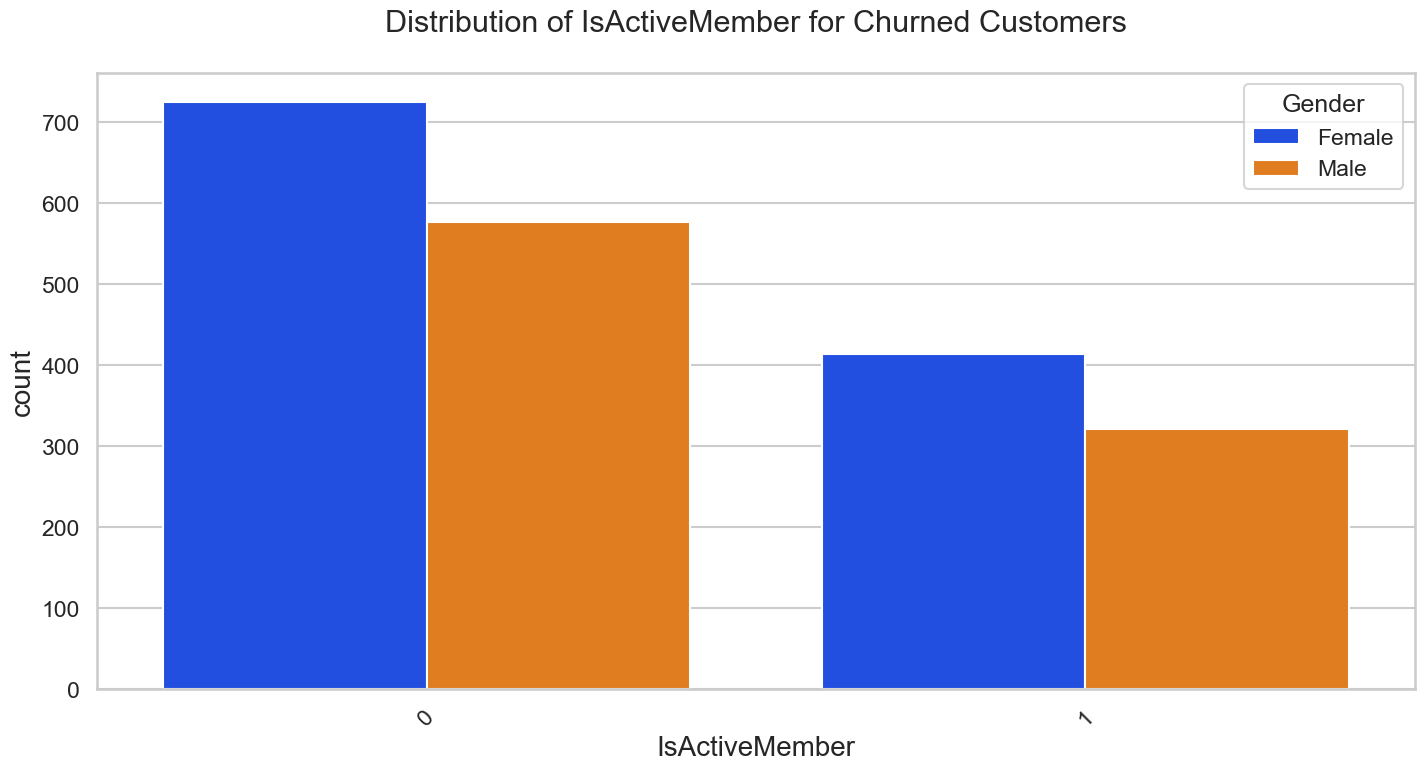

In [35]:
uniplot(
    new_df1_target1,
    col='IsActiveMember',
    title='Distribution of IsActiveMember for Churned Customers',
    hue='Gender'
)

-Most of the customer who churned is not activemember which most is female 

Bivarate analysis for Age_group  churned 

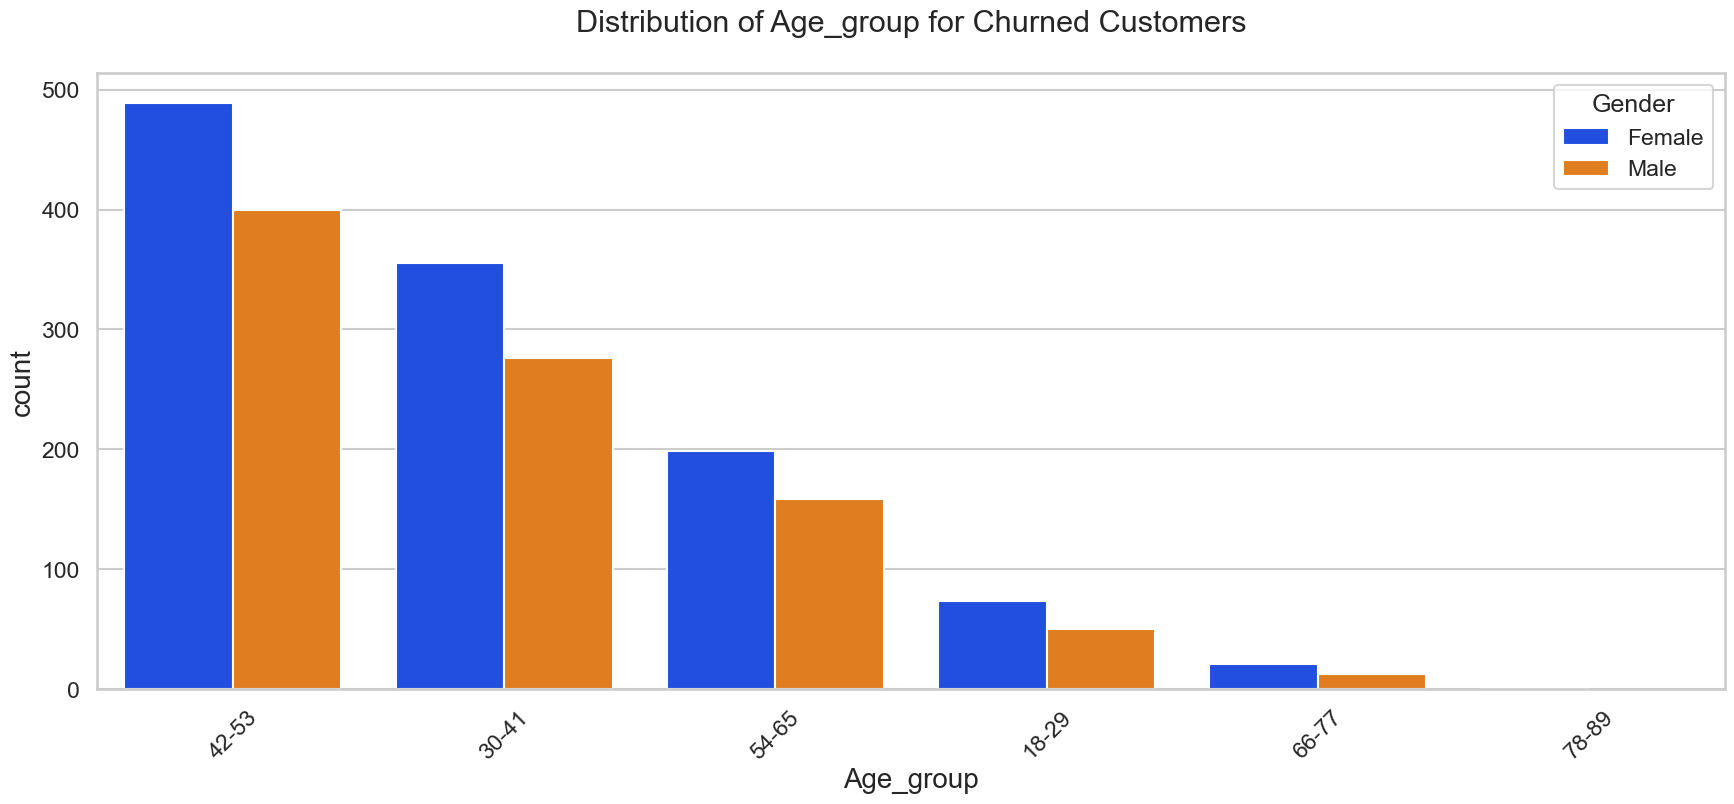

In [36]:
uniplot(
    new_df1_target1,
    col='Age_group',
    title='Distribution of Age_group for Churned Customers',
    hue='Gender'
)

-Customer churn is highest among middle-aged customers, especially those aged 42–53, for both genders.
The 30–41 age group also shows significant churn, while the youngest (18–29) and oldest (66+) groups have very low churn.
Females consistently exhibit higher churn than males across all age groups, indicating a gender-related pattern.

#### CONCLUSION

These are some of the quick insights from this analysis:
- Customer churn rate is around **20%**, indicating a moderate but significant churn problem.
- **Germany** has the highest churn rate, while **Spain** has the lowest.
- **Female customers** are more likely to churn compared to male customers across all regions.
- **Middle-aged customers (30–53 years)** show the highest churn, especially those aged **42–53**.
- **Inactive members** are the highest churners, showing engagement is a key retention factor.
- Customers with **only one product** have the highest churn, while holding more products reduces churn.
- Customers with **higher account balances** are more likely to churn than those with low or zero balances.
- **Short and mid-tenure customers** churn more, while long-tenured customers are more loyal.
- Customers **owning credit cards**, particularly females, show higher churn compared to those without cards.


### MODEL CREATION:

In [7]:
#Importing Libraries
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN

In [8]:
bank_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# make copy of the dataset
bank_churn_2 = bank_churn.copy()

In [10]:
# Remove column that are not needed
bank_churn_2.drop(columns= ['RowNumber','CustomerId','Surname'], axis=1, inplace=True)
bank_churn_2.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [11]:
#make the encoding of the category column
# Identify categorical columns
object_columns = bank_churn_2.select_dtypes(include=['object']).columns

# Apply dummy encoding
bank_churn_dummies = pd.get_dummies(
    bank_churn_2,
    columns=object_columns,
    drop_first=True,   # avoid dummy variable trap
    dtype=int
)
bank_churn_dummies.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [12]:
bank_churn_dummies.to_csv("bank_churn_dummies.csv",index=False)

In [13]:
bank_churn_3 = bank_churn_dummies.copy()

In [14]:
# Divide the data into dependents and independents
x=bank_churn_3.drop(['Exited'], axis=1)
y=bank_churn_3['Exited']

In [15]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [16]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [17]:
# Splitting the data into training & test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
print(f"X_train:{len(x_train)}, X_test:{len(x_test)}")

X_train:8000, X_test:2000


In [18]:
print(x_train.shape, y_train.shape)
print(x_test.shape,y_test.shape)

(8000, 11) (8000,)
(2000, 11) (2000,)


In [19]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)

In [20]:
x_train

array([[-0.90750816, -0.57240715,  0.33644908, ..., -0.56849704,
        -0.57427105,  0.90088523],
       [-0.03593925, -0.85836051,  1.71692999, ...,  1.75902411,
        -0.57427105, -1.1100193 ],
       [ 0.73187146, -0.19113599, -1.04403183, ..., -0.56849704,
        -0.57427105, -1.1100193 ],
       ...,
       [ 1.55156127,  2.2871265 , -1.38915205, ..., -0.56849704,
        -0.57427105, -1.1100193 ],
       [-0.48209952,  0.09481737,  1.02668953, ...,  1.75902411,
        -0.57427105, -1.1100193 ],
       [-1.46780246,  1.4292664 ,  1.71692999, ..., -0.56849704,
         1.74133801,  0.90088523]])

In [21]:
x_test

array([[-2.53651196e+00, -5.00418388e-04,  1.71692999e+00, ...,
        -5.68497041e-01, -5.74271046e-01,  9.00885233e-01],
       [ 6.78189561e-02, -1.14431388e+00, -6.98911599e-01, ...,
         1.75902411e+00, -5.74271046e-01, -1.11001930e+00],
       [-3.36838039e-01, -1.23963166e+00, -1.04403183e+00, ...,
        -5.68497041e-01, -5.74271046e-01, -1.11001930e+00],
       ...,
       [ 2.08072811e+00, -8.58360511e-01,  1.37180976e+00, ...,
        -5.68497041e-01, -5.74271046e-01,  9.00885233e-01],
       [ 2.64959544e-01,  2.85452946e-01, -1.04403183e+00, ...,
         1.75902411e+00, -5.74271046e-01,  9.00885233e-01],
       [-2.36012302e+00, -5.72407147e-01, -1.04403183e+00, ...,
        -5.68497041e-01, -5.74271046e-01, -1.11001930e+00]])

In [52]:
# Save the scaler
import pickle
with open('scaler.sav', 'wb') as f:
    pickle.dump(sc, f)

#### Decision Tree Classifier

In [53]:
model_dt=DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=6, min_samples_leaf=8)
model_dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [54]:
y_pred=model_dt.predict(x_test)
y_pred

array([1, 0, 0, ..., 0, 1, 1], dtype=int64)

In [55]:
model_dt.score(x_test,y_test)

0.8515

In [56]:
print(classification_report(y_test, y_pred, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1600
           1       0.73      0.41      0.52       400

    accuracy                           0.85      2000
   macro avg       0.80      0.68      0.72      2000
weighted avg       0.84      0.85      0.83      2000



As you can see that the accuracy is not bad but sometimes accurancy can be misleading, and as it's an imbalanced dataset, we shouldn't consider Accuracy as our metrics to measure the model, as Accuracy is cursed in imbalanced datasets.
Hence, we need to check recall, precision & f1 score for the minority class, and it's quite evident that the precision, recall & f1 score is too low for Class 1, i.e. churned customers.<br>
Hence, moving ahead to call SMOTEENN (UpSampling + ENN)

In [57]:
sm = SMOTEENN()
X_resampled, y_resampled = sm.fit_resample(x,y)

In [58]:
xr_train,xr_test,yr_train,yr_test=train_test_split(X_resampled, y_resampled,test_size=0.2)

In [59]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xr_train = sc.fit_transform(xr_train)
xr_test  = sc.transform(xr_test)

In [60]:
model_dt_smote=DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=6, min_samples_leaf=8)

In [61]:
model_dt_smote.fit(xr_train,yr_train)
yr_predict = model_dt_smote.predict(xr_test)

In [62]:
yr_predict

array([0, 0, 1, ..., 1, 0, 1], dtype=int64)

In [63]:
model_score_r = model_dt_smote.score(xr_test, yr_test)
print(model_score_r)
print(metrics.classification_report(yr_test, yr_predict))

0.8226788432267884
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       587
           1       0.84      0.83      0.84       727

    accuracy                           0.82      1314
   macro avg       0.82      0.82      0.82      1314
weighted avg       0.82      0.82      0.82      1314



In [64]:
print(metrics.confusion_matrix(yr_test, yr_predict))

[[475 112]
 [121 606]]


#### Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
model_rf=RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)

In [24]:
model_rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [25]:
y_pred=model_rf.predict(x_test)
model_rf.score(x_test,y_test)

0.85

In [26]:
print(classification_report(y_test, y_pred, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91      1568
           1       0.87      0.36      0.51       432

    accuracy                           0.85      2000
   macro avg       0.86      0.67      0.71      2000
weighted avg       0.85      0.85      0.82      2000



In [27]:
sm = SMOTEENN()
X_resampled1, y_resampled1 = sm.fit_resample(x,y)

In [28]:
xr_train1,xr_test1,yr_train1,yr_test1=train_test_split(X_resampled1, y_resampled1,test_size=0.2)

In [29]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_rfs = StandardScaler()
xr_train1 = sc_rfs.fit_transform(xr_train1)
xr_test1  = sc_rfs.transform(xr_test1)

In [30]:
model_rf_smote=RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)

In [31]:
model_rf_smote.fit(xr_train1,yr_train1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [32]:
yr_predict1 = model_rf_smote.predict(xr_test1)

In [33]:
model_score_r1 = model_rf_smote.score(xr_test1, yr_test1)

In [34]:
print(model_score_r1)
print(metrics.classification_report(yr_test1, yr_predict1))

0.8443579766536965
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       559
           1       0.86      0.87      0.86       726

    accuracy                           0.84      1285
   macro avg       0.84      0.84      0.84      1285
weighted avg       0.84      0.84      0.84      1285



In [35]:
print(metrics.confusion_matrix(yr_test1, yr_predict1))

[[453 106]
 [ 94 632]]


In [37]:
# Save the scaler
import pickle
with open('scaler.sav', 'wb') as f:
    pickle.dump(sc_rfs, f)

###### With RF Classifier, also we are able to get quite good results, infact better than Decision Tree.

#### kNN Classifier

In [80]:
# Call the kNN Classifier
from sklearn.neighbors import KNeighborsClassifier

# Initiating the classifier
model_knn = KNeighborsClassifier()

# Passing the data to classifier
model_knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [82]:
y_pred = model_knn.predict(x_test)

In [83]:
y_pred

array([1, 0, 0, ..., 0, 1, 1], dtype=int64)

In [84]:
y_test

3848    0
2368    0
7210    0
1266    0
2231    0
       ..
217     0
2875    0
5324    0
3616    1
5137    1
Name: Exited, Length: 2000, dtype: int64

In [85]:
model_knn.score(x_test,y_test)

0.8125

In [86]:
print(classification_report(y_test, y_pred, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.85      0.92      0.89      1600
           1       0.55      0.37      0.44       400

    accuracy                           0.81      2000
   macro avg       0.70      0.65      0.67      2000
weighted avg       0.79      0.81      0.80      2000



In [87]:
sm = SMOTEENN()
X_resampled2, y_resampled2 = sm.fit_resample(x,y)

In [88]:
xr_train2,xr_test2,yr_train2,yr_test2=train_test_split(X_resampled2, y_resampled2,test_size=0.2)

In [89]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xr_train2 = sc.fit_transform(xr_train2)
xr_test2  = sc.transform(xr_test2)

In [90]:
model_knn_smote=KNeighborsClassifier()
model_knn_smote.fit(xr_train2,yr_train2)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [91]:
yr_predict2=model_knn_smote.predict(xr_test2)
model_score_r2 = model_knn_smote.score(xr_test2, yr_test2)

In [92]:
print(model_score_r2)
print(metrics.classification_report(yr_test2, yr_predict2))

0.8389312977099237
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       572
           1       0.85      0.87      0.86       738

    accuracy                           0.84      1310
   macro avg       0.84      0.83      0.84      1310
weighted avg       0.84      0.84      0.84      1310



In [93]:
print(metrics.confusion_matrix(yr_test2, yr_predict2))

[[458 114]
 [ 97 641]]


#### Naive Bayes Classifier

In [94]:
# Call the Random Forest Classifier
from sklearn.naive_bayes import BernoulliNB

# Initiating the classifier
model_nb = BernoulliNB()

In [95]:
# Passing the data to classifier
model_nb.fit(x_train, y_train)

# Predictions
y_pred_nb = model_nb.predict(x_test)

In [96]:
model_nb.score(x_test,y_test)

0.8145

In [97]:
print(classification_report(y_test, y_pred_nb, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1600
           1       0.58      0.27      0.37       400

    accuracy                           0.81      2000
   macro avg       0.71      0.61      0.63      2000
weighted avg       0.79      0.81      0.79      2000



In [98]:
sm = SMOTEENN()
X_resampled3, y_resampled3 = sm.fit_resample(x,y)

In [99]:
xr_train3,xr_test3,yr_train3,yr_test3=train_test_split(X_resampled3, y_resampled3,test_size=0.2)

In [100]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xr_train3 = sc.fit_transform(xr_train3)
xr_test3  = sc.transform(xr_test3)

In [101]:
model_nb_smote=BernoulliNB()
model_nb_smote.fit(xr_train3,yr_train3)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [102]:
yr_predict3=model_nb_smote.predict(xr_test3)
model_score_r3 = model_nb_smote.score(xr_test3, yr_test3)

In [103]:
print(model_score_r3)
print(metrics.classification_report(yr_test3, yr_predict3))

0.8041315990818668
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       576
           1       0.81      0.85      0.83       731

    accuracy                           0.80      1307
   macro avg       0.80      0.80      0.80      1307
weighted avg       0.80      0.80      0.80      1307



In [104]:
print(metrics.confusion_matrix(yr_test3, yr_predict3))

[[433 143]
 [113 618]]


#### SVM Classifier

In [105]:
# Call the Random Forest Classifier
from sklearn.svm import SVC

# Initiating the classifier
model_svc = SVC()

# Passing the data to classifier
model_svc.fit(x_train, y_train)

# Predictions
y_pred_svc = model_svc.predict(x_test)

In [106]:
model_svc.score(x_test,y_test)

0.854

In [107]:
print(classification_report(y_test, y_pred_svc, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1600
           1       0.77      0.38      0.51       400

    accuracy                           0.85      2000
   macro avg       0.82      0.68      0.71      2000
weighted avg       0.84      0.85      0.83      2000



In [108]:
sm = SMOTEENN()
X_resampled4, y_resampled4 = sm.fit_resample(x,y)

In [109]:
xr_train4,xr_test4,yr_train4,yr_test4=train_test_split(X_resampled4, y_resampled4,test_size=0.2)

In [110]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xr_train4 = sc.fit_transform(xr_train4)
xr_test4  = sc.transform(xr_test4)

In [111]:
model_svc_smote=BernoulliNB()
model_svc_smote.fit(xr_train4,yr_train4)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [112]:
yr_predict4=model_svc_smote.predict(xr_test4)
model_score_r4 = model_svc_smote.score(xr_test4, yr_test4)

In [113]:
print(model_score_r4)
print(metrics.classification_report(yr_test4, yr_predict4))

0.7924528301886793
              precision    recall  f1-score   support

           0       0.80      0.73      0.76       606
           1       0.79      0.84      0.82       719

    accuracy                           0.79      1325
   macro avg       0.79      0.79      0.79      1325
weighted avg       0.79      0.79      0.79      1325



In [114]:
print(metrics.confusion_matrix(yr_test4, yr_predict4))

[[443 163]
 [112 607]]


 #### Logistic Regression Classifier

In [115]:
# Call the Random Forest Classifier
from sklearn.linear_model import LogisticRegression

# Initiating the classifier
model_lr = LogisticRegression()

# Passing the data to classifier
model_lr.fit(x_train, y_train)

# Predictions
y_pred_lr = model_lr.predict(x_test)

In [116]:
model_lr.score(x_test,y_test)

0.817

In [117]:
lr_report = classification_report(y_test, y_pred_lr)
print(lr_report)

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1600
           1       0.62      0.23      0.33       400

    accuracy                           0.82      2000
   macro avg       0.72      0.59      0.61      2000
weighted avg       0.79      0.82      0.78      2000



In [118]:
sm = SMOTEENN()
X_resampled5, y_resampled5 = sm.fit_resample(x,y)

In [119]:
xr_train5,xr_test5,yr_train5,yr_test5=train_test_split(X_resampled5, y_resampled5,test_size=0.2)

In [120]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xr_train5 = sc.fit_transform(xr_train5)
xr_test5  = sc.transform(xr_test5)

In [121]:
model_lr_smote=LogisticRegression()
model_lr_smote.fit(xr_train5,yr_train5)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [122]:
yr_predict5=model_lr_smote.predict(xr_test5)
model_score_r5 = model_lr_smote.score(xr_test5, yr_test5)

In [123]:
print(model_score_r5)
print(metrics.classification_report(yr_test5, yr_predict5))

0.8190839694656489
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       575
           1       0.84      0.84      0.84       735

    accuracy                           0.82      1310
   macro avg       0.82      0.82      0.82      1310
weighted avg       0.82      0.82      0.82      1310



In [124]:
print(metrics.confusion_matrix(yr_test5, yr_predict5))

[[456 119]
 [118 617]]


#### XGboost   Classifier

In [125]:
import numpy as np

neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)

print("Non-churn:", neg_count)
print("Churn:", pos_count)


Non-churn: 6363
Churn: 1637


In [126]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    scale_pos_weight=neg_count / pos_count,
    eval_metric="logloss",
    random_state=42
)

In [127]:
# Passing the data to classifier
model_xgb.fit(x_train, y_train)

# Predictions
y_pred_xgb = model_xgb.predict(x_test)

In [128]:
model_xgb.score(x_test,y_test)

0.8225

In [129]:
xgb_report = classification_report(y_test, y_pred_xgb)
print(xgb_report)

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1600
           1       0.55      0.64      0.59       400

    accuracy                           0.82      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.82      0.83      2000



In [130]:
sm = SMOTEENN()
X_resampled6, y_resampled6 = sm.fit_resample(x,y)

In [131]:
xr_train6,xr_test6,yr_train6,yr_test6=train_test_split(X_resampled6, y_resampled6,test_size=0.2)

In [132]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc6 = StandardScaler()
xr_train6 = sc.fit_transform(xr_train6)
xr_test6  = sc.transform(xr_test6)

In [133]:
# Save the scaler
with open('scaler.sav', 'wb') as f:
    pickle.dump(sc6, f)

In [134]:
neg_counts = np.sum(yr_train6 == 1)
pos_counts = np.sum(yr_train6 == 0)

print("Churn:", neg_counts)
print("Non-churn:", pos_counts)

Churn: 2901
Non-churn: 2341


In [135]:
model_xgb_smote = XGBClassifier(
    scale_pos_weight=neg_count / pos_count,
    eval_metric="logloss",
    random_state=42
)
# Passing the data to classifier
model_xgb_smote.fit(xr_train6, yr_train6)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [136]:
yr_predict6=model_xgb_smote.predict(xr_test6)
model_score_r6 = model_xgb_smote.score(xr_test6, yr_test6)

In [137]:
print(model_score_r6)
print(metrics.classification_report(yr_test6, yr_predict6))

0.8695652173913043
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       559
           1       0.85      0.93      0.89       752

    accuracy                           0.87      1311
   macro avg       0.87      0.86      0.86      1311
weighted avg       0.87      0.87      0.87      1311



In [138]:
print(metrics.confusion_matrix(yr_test6, yr_predict6))

[[439 120]
 [ 51 701]]


Among all evaluated models, the XGBoost classifier achieved the best performance, with the highest accuracy (86%), macro F1-score (86%), and recall for the positive class (95%), indicating superior ability to correctly identify positive cases compared to other models. follwed by Random Forest

- This is ensamble model: Scenario Best Ensemble Overall best XGBoost Large dataset LightGBM Many categorical features CatBoost Simple & interpretable Random Forest

#### Performing PCA

In [139]:
# Applying PCA
from sklearn.decomposition import PCA
pca = PCA(0.9)
xr_train_pca = pca.fit_transform(xr_train6)
xr_test_pca = pca.transform(xr_test6)
explained_variance = pca.explained_variance_ratio_

In [140]:
model_xgb_pca = XGBClassifier(
    scale_pos_weight=neg_count / pos_count,
    eval_metric="logloss",
    random_state=42
)
# Passing the data to classifier
model_xgb_pca.fit(xr_train_pca, yr_train6)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [141]:
yr_predict_pca = model_xgb_pca.predict(xr_test_pca)

In [142]:
model_score_r_pca =model_xgb_pca.score(xr_test_pca, yr_test6)

In [143]:
print(model_score_r_pca)
print(metrics.classification_report(yr_test6, yr_predict_pca))

0.8306636155606407
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       559
           1       0.82      0.91      0.86       752

    accuracy                           0.83      1311
   macro avg       0.84      0.82      0.82      1311
weighted avg       0.83      0.83      0.83      1311



##### With PCA, we couldn't see any better results, hence let's finalise the model which was created by Xgboost Classifier with smotten, and save the model so that we can use it in a later stage :)

Pickling the model

In [144]:
import pickle
with open('finalized_model1.sav', 'wb') as file:
    pickle.dump(model_rf_smote, file)


In [145]:
with open('finalized_model1.sav', 'rb') as file:
    loaded_model = pickle.load(file)

# Make predictions
y_pred_final = loaded_model.predict(x_test)

In [146]:
y_pred_final[4]


1